## TP de Machine Learning
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

**Date :** 23 Avril 2026

---

Ce notebook implémente **6 algorithmes** de Machine Learning :
- 3 algorithmes de **Régression** (Linéaire Simple, Multiple, Polynomiale)
- 3 algorithmes de **Classification** (Régression Logistique, KNN, SVM)

Chaque algorithme est comparé entre une implémentation **From Scratch** et une implémentation via la biblio **Scikit-Learn**.

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
# Pandas est utilisé pour charger et manipuler notre jeu de données (fichiers CSV)
import pandas as pd
# Numpy est le moteur mathématique, utilisé ici pour l'algèbre linéaire (matrices)
import numpy as np
# Matplotlib permet de tracer les graphiques et de visualiser nos résultats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Scikit-Learn fournit les implémentations professionnelles pour comparer nos calculs
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Commande magique Jupyter pour forcer l'affichage des graphiques directement sous les cellules
%matplotlib inline

### IMPLÉMENTATION DE L'ÉQUATION NORMALE (RÉGRESSION)

In [2]:
class RegressionFromScratch:
    def __init__(self):
        # theta contiendra nos poids optimaux (l'ordonnée à l'origine et les pentes)
        self.theta = None

    def fit(self, X_train, y_train):
        # ÉTAPE 1 : Ajouter une colonne de 1 à la matrice X
        # Cela permet de calculer le biais (beta_0 ou l'ordonnée à l'origine)
        X_b = np.c_[np.ones((len(X_train), 1)), X_train]
        
        # ÉTAPE 2 : Appliquer l'Équation Normale
        # Formule mathématique : theta = (X^T * X)^-1 * X^T * y
        # - .T effectue la transposée de la matrice
        # - .dot() effectue la multiplication matricielle
        # - np.linalg.inv() calcule l'inverse de la matrice
        self.theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)

    def predict(self, X_test):
        # Pour prédire de nouvelles valeurs, on ajoute aussi la colonne de 1
        X_b = np.c_[np.ones((len(X_test), 1)), X_test]
        # On multiplie les nouvelles données par les poids calculés
        return X_b.dot(self.theta)

### IMPLÉMENTATIONS FROM SCRATCH (CLASSIFICATION)

In [3]:
class LogisticRegressionFromScratch:
    """
    Régression logistique implémentée manuellement via la descente de gradient.
    Utilise la fonction sigmoïde pour modéliser la probabilité d'appartenance à une classe.
    """
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        # La fonction sigmoïde transforme une valeur en probabilité entre 0 et 1
        # Le clip évite les dépassements numériques (overflow)
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X_train, y_train):
        n_samples, n_features = X_train.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iterations):
            # Prédiction linéaire puis application de la sigmoïde
            z = X_train.dot(self.weights) + self.bias
            predictions = self._sigmoid(z)

            # Calcul des gradients (dérivées partielles de la fonction de coût)
            dw = (1 / n_samples) * X_train.T.dot(predictions - y_train)
            db = (1 / n_samples) * np.sum(predictions - y_train)

            # Mise à jour des poids par descente de gradient
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X_test):
        z = X_test.dot(self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X_test):
        return (self.predict_proba(X_test) >= 0.5).astype(int)


class KNNFromScratch:
    """
    K Plus Proches Voisins (KNN) implémenté manuellement.
    Utilise la distance euclidienne et le vote majoritaire pour la classification.
    """
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        # KNN ne fait pas d'apprentissage, il mémorise les données d'entraînement
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        for x in X_test:
            # Calcul de la distance euclidienne vers tous les points d'entraînement
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            # Sélection des K voisins les plus proches
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            # Vote majoritaire pour déterminer la classe
            prediction = int(np.round(np.mean(k_labels)))
            predictions.append(prediction)
        return np.array(predictions)

### PRÉPARATION DES DONNÉES

In [4]:
# Chargement du fichier CSV contenant les coûts médicaux
df = pd.read_csv('data/medical_costs.csv')

# === Variables pour la Régression ===
# X_simple = Âge du patient | y = Coût médical associé
X_simple = df[['age']].values
y = df[['cost']].values
# X_multi = Âge, Indice de Masse Corporelle (BMI), et Nombre d'enfants
X_multi = df[['age', 'bmi', 'children']].values

# === Variables pour la Classification ===
# On crée une variable cible binaire : 1 si le coût est >= à la médiane, 0 sinon
median_cost = np.median(df['cost'].values)
y_class = (df['cost'].values >= median_cost).astype(int)
X_class = df[['age', 'bmi']].values  # 2 variables pour permettre la visualisation 2D

# Séparation en ensembles d'entraînement (80%) et de test (20%)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Normalisation des caractéristiques (essentiel pour KNN et SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cls)
X_test_scaled = scaler.transform(X_test_cls)

# Grille pour tracer les frontières de décision
h = 0.5
x_min, x_max = X_class[:, 0].min() - 2, X_class[:, 0].max() + 2
y_min, y_max = X_class[:, 1].min() - 2, X_class[:, 1].max() + 2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points_scaled = scaler.transform(grid_points)

# Couleurs pour la visualisation des classes
class_colors = np.where(y_class == 1, '#e74c3c', '#3498db')

print(f"Nombre total d'échantillons : {len(df)}")
print(f"Entraînement : {len(X_train_cls)} | Test : {len(X_test_cls)}")
print(f"Seuil de classification (médiane du coût) : {median_cost:.2f}")

Nombre total d'échantillons : 500
Entraînement : 400 | Test : 100
Seuil de classification (médiane du coût) : 17141.39


### TEST 1 : RÉGRESSION LINÉAIRE SIMPLE

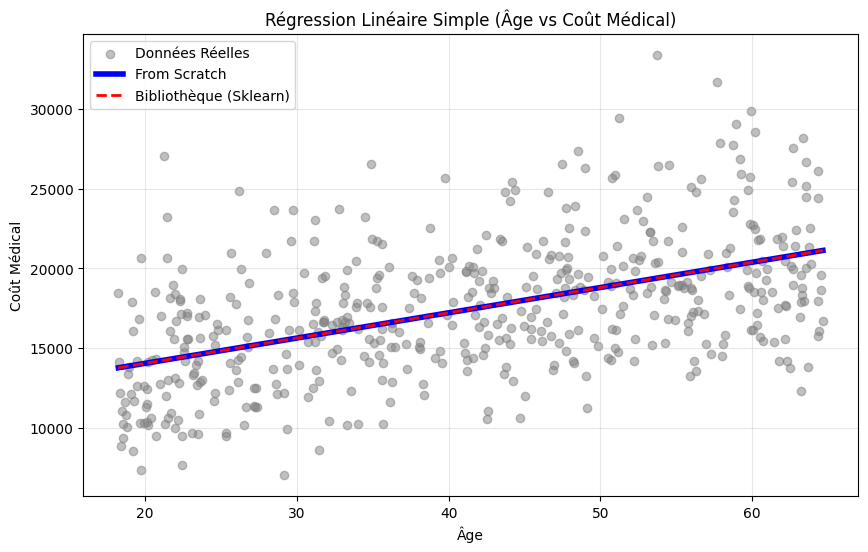

In [5]:
# ==========================================
# Objectif : Prédire le coût uniquement à partir de l'âge
# ==========================================

# 1. Entraînement de notre modèle manuel
model_simple = RegressionFromScratch()
model_simple.fit(X_simple, y)

# 2. Entraînement du modèle de la bibliothèque (Scikit-Learn) pour vérification
sk_simple = LinearRegression().fit(X_simple, y)

# 3. Création d'une ligne continue pour tracer nos prédictions proprement
X_plot = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)

# 4. Visualisation
plt.figure(figsize=(10, 6))
# Affichage des vraies données en gris
plt.scatter(X_simple, y, color='gray', alpha=0.5, label='Données Réelles')
# Affichage de notre droite mathématique (Épaisse et bleue)
plt.plot(X_plot, model_simple.predict(X_plot), color='blue', linewidth=4, label='From Scratch')
# Affichage de la droite de Scikit-Learn (Pointillée et rouge, superposée à la nôtre)
plt.plot(X_plot, sk_simple.predict(X_plot), color='red', linestyle='dashed', linewidth=2, label='Bibliothèque (Sklearn)')

# Formatage du graphique
plt.title('Régression Linéaire Simple (Âge vs Coût Médical)')
plt.xlabel('Âge')
plt.ylabel('Coût Médical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TEST 2 : RÉGRESSION LINÉAIRE MULTIPLE

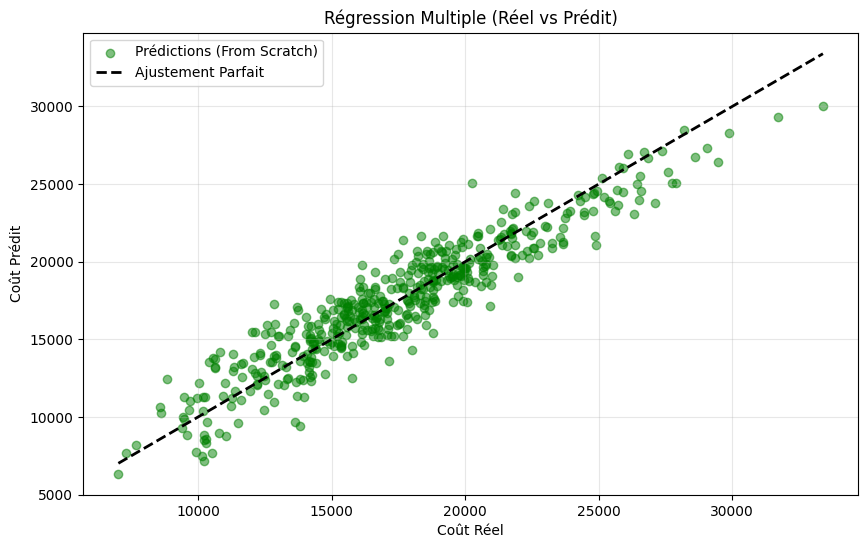

In [6]:
# ==========================================
# Objectif : Prédire le coût à partir de l'âge, du BMI et du nombre d'enfants
# ==========================================

# 1. Entraînement de notre modèle manuel
model_multi = RegressionFromScratch()
model_multi.fit(X_multi, y)

# 2. Entraînement du modèle Scikit-Learn
sk_multi = LinearRegression().fit(X_multi, y)

# 3. Prédictions From Scratch sur les données d'entraînement
y_pred_multi = model_multi.predict(X_multi)

# 4. Visualisation (Coût Réel vs Coût Prédit)
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred_multi, color='green', alpha=0.5, label='Prédictions (From Scratch)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='black', linestyle='dashed', lw=2, label='Ajustement Parfait')

plt.title('Régression Multiple (Réel vs Prédit)')
plt.xlabel('Coût Réel')
plt.ylabel('Coût Prédit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TEST 3 : RÉGRESSION POLYNOMIALE

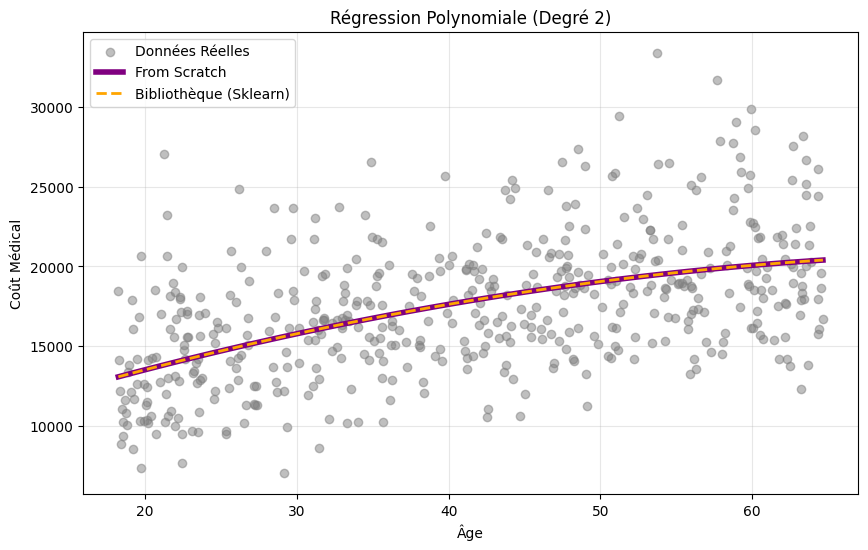

In [7]:
# ==========================================
# Objectif : Modéliser une relation non-linéaire entre l'âge et le coût
# ==========================================

# 1. Créer les variables polynomiales manuellement (degré 2)
X_poly_scratch = np.c_[X_simple, X_simple**2]
model_poly = RegressionFromScratch()
model_poly.fit(X_poly_scratch, y)

# 2. Utiliser Scikit-Learn pour les mêmes variables polynomiales
poly_feats = PolynomialFeatures(degree=2, include_bias=False)
X_poly_sk = poly_feats.fit_transform(X_simple)
sk_poly = LinearRegression().fit(X_poly_sk, y)

# 3. Prédictions sur une ligne continue
X_plot_poly = np.c_[X_plot, X_plot**2]
X_plot_poly_sk = poly_feats.transform(X_plot)

# 4. Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y, color='gray', alpha=0.5, label='Données Réelles')
plt.plot(X_plot, model_poly.predict(X_plot_poly), color='purple', linewidth=4, label='From Scratch')
plt.plot(X_plot, sk_poly.predict(X_plot_poly_sk), color='orange', linestyle='dashed', linewidth=2, label='Bibliothèque (Sklearn)')

plt.title('Régression Polynomiale (Degré 2)')
plt.xlabel('Âge')
plt.ylabel('Coût Médical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TEST 4 : RÉGRESSION LOGISTIQUE (Classification)

Précision From Scratch : 89.0%
Précision Bibliothèque : 89.0%


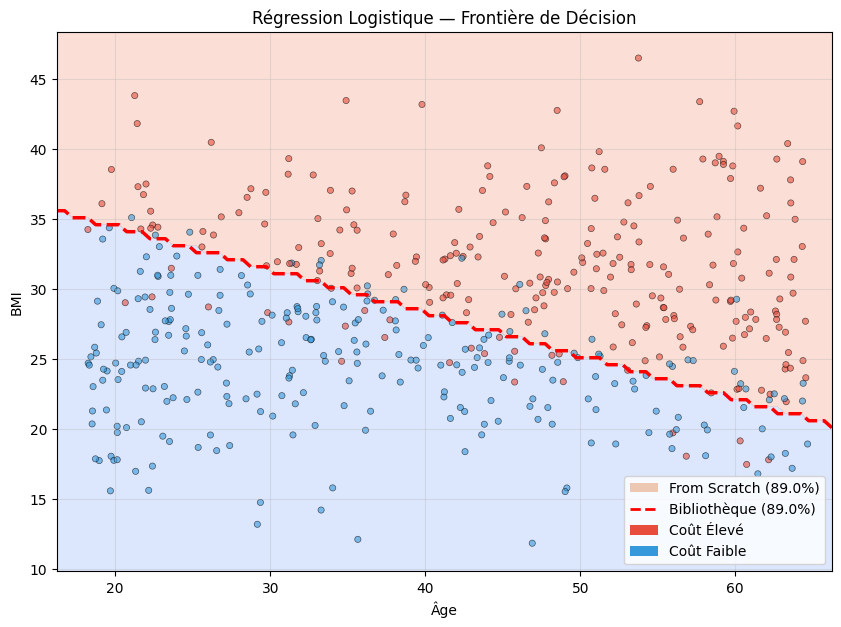

In [8]:
# ==========================================
# Objectif : Classifier les patients en 2 catégories (coût élevé/faible)
# ==========================================

# 1. Entraînement du modèle From Scratch (descente de gradient)
model_log_scratch = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=1000)
model_log_scratch.fit(X_train_scaled, y_train_cls)
y_pred_log_scratch = model_log_scratch.predict(X_test_scaled)
acc_log_scratch = accuracy_score(y_test_cls, y_pred_log_scratch)

# 2. Entraînement du modèle Scikit-Learn
model_log_sklearn = SklearnLogisticRegression(max_iter=1000)
model_log_sklearn.fit(X_train_scaled, y_train_cls)
y_pred_log_sklearn = model_log_sklearn.predict(X_test_scaled)
acc_log_sklearn = accuracy_score(y_test_cls, y_pred_log_sklearn)

print(f"Précision From Scratch : {acc_log_scratch:.1%}")
print(f"Précision Bibliothèque : {acc_log_sklearn:.1%}")

# 3. Calcul des frontières de décision
Z_log_scratch = model_log_scratch.predict(grid_points_scaled).reshape(xx.shape)
Z_log_sklearn = model_log_sklearn.predict(grid_points_scaled).reshape(xx.shape)

# 4. Visualisation
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_log_scratch, alpha=0.3, cmap='coolwarm',
             levels=np.linspace(-0.5, 1.5, 3))
plt.contour(xx, yy, Z_log_sklearn, colors='red', linestyles='dashed',
            linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:, 0], X_class[:, 1], c=class_colors,
            edgecolors='black', s=20, alpha=0.6, linewidths=0.5)

plt.title('Régression Logistique — Frontière de Décision')
plt.xlabel('Âge')
plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label=f'From Scratch ({acc_log_scratch:.1%})'),
    Line2D([0], [0], color='red', linestyle='dashed', linewidth=2,
           label=f'Bibliothèque ({acc_log_sklearn:.1%})'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible'),
])
plt.grid(True, alpha=0.3)
plt.show()

### TEST 5 : KNN (K Plus Proches Voisins)

Précision From Scratch : 89.0%
Précision Bibliothèque : 89.0%
Calcul des frontières de décision KNN...
Terminé !


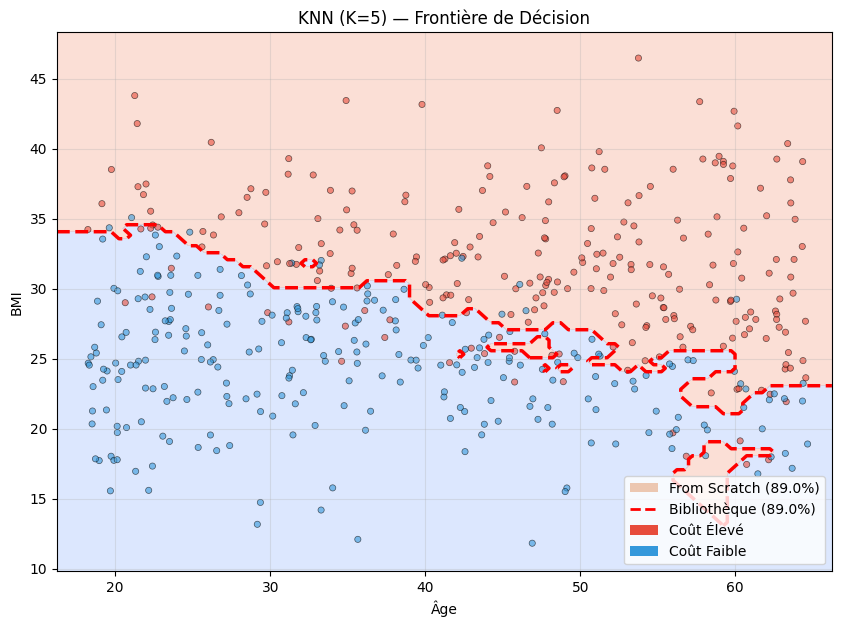

In [11]:
# ==========================================
# Objectif : Classifier via les K plus proches voisins
# ==========================================

# 1. Entraînement du modèle From Scratch (K=5)
model_knn_scratch = KNNFromScratch(k=5)
model_knn_scratch.fit(X_train_scaled, y_train_cls)
y_pred_knn_scratch = model_knn_scratch.predict(X_test_scaled)
acc_knn_scratch = accuracy_score(y_test_cls, y_pred_knn_scratch)

# 2. Entraînement du modèle Scikit-Learn
model_knn_sklearn = KNeighborsClassifier(n_neighbors=5)
model_knn_sklearn.fit(X_train_scaled, y_train_cls)
y_pred_knn_sklearn = model_knn_sklearn.predict(X_test_scaled)
acc_knn_sklearn = accuracy_score(y_test_cls, y_pred_knn_sklearn)

print(f"Précision From Scratch : {acc_knn_scratch:.1%}")
print(f"Précision Bibliothèque : {acc_knn_sklearn:.1%}")

# 3. Calcul des frontières de décision (peut prendre quelques secondes)
print("Calcul des frontières de décision KNN...")
Z_knn_scratch = model_knn_scratch.predict(grid_points_scaled).reshape(xx.shape)
Z_knn_sklearn = model_knn_sklearn.predict(grid_points_scaled).reshape(xx.shape)
print("Terminé !")

# 4. Visualisation
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_knn_scratch, alpha=0.3, cmap='coolwarm',
             levels=np.linspace(-0.5, 1.5, 3))
plt.contour(xx, yy, Z_knn_sklearn, colors='red', linestyles='dashed',
            linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:, 0], X_class[:, 1], c=class_colors,
            edgecolors='black', s=20, alpha=0.6, linewidths=0.5)

plt.title('KNN (K=5) — Frontière de Décision')
plt.xlabel('Âge')
plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label=f'From Scratch ({acc_knn_scratch:.1%})'),
    Line2D([0], [0], color='red', linestyle='dashed', linewidth=2,
           label=f'Bibliothèque ({acc_knn_sklearn:.1%})'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible'),
])
plt.grid(True, alpha=0.3)
plt.show()

### TEST 6 : SVM (Machine à Vecteurs de Support)

Précision Noyau Linéaire : 90.0%
Précision Noyau RBF      : 92.0%


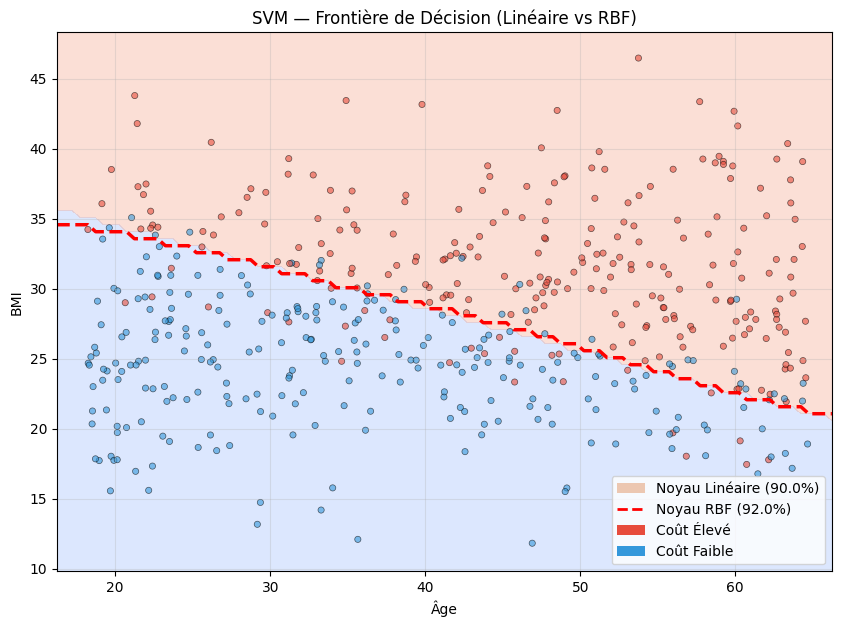

In [10]:
# ==========================================
# Objectif : Comparer deux noyaux SVM (Linéaire vs RBF)
# ==========================================

# 1. SVM avec noyau linéaire
model_svm_linear = SVC(kernel='linear')
model_svm_linear.fit(X_train_scaled, y_train_cls)
y_pred_svm_linear = model_svm_linear.predict(X_test_scaled)
acc_svm_linear = accuracy_score(y_test_cls, y_pred_svm_linear)

# 2. SVM avec noyau RBF (Gaussien)
model_svm_rbf = SVC(kernel='rbf')
model_svm_rbf.fit(X_train_scaled, y_train_cls)
y_pred_svm_rbf = model_svm_rbf.predict(X_test_scaled)
acc_svm_rbf = accuracy_score(y_test_cls, y_pred_svm_rbf)

print(f"Précision Noyau Linéaire : {acc_svm_linear:.1%}")
print(f"Précision Noyau RBF      : {acc_svm_rbf:.1%}")

# 3. Calcul des frontières de décision
Z_svm_linear = model_svm_linear.predict(grid_points_scaled).reshape(xx.shape)
Z_svm_rbf = model_svm_rbf.predict(grid_points_scaled).reshape(xx.shape)

# 4. Visualisation
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_svm_linear, alpha=0.3, cmap='coolwarm',
             levels=np.linspace(-0.5, 1.5, 3))
plt.contour(xx, yy, Z_svm_rbf, colors='red', linestyles='dashed',
            linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:, 0], X_class[:, 1], c=class_colors,
            edgecolors='black', s=20, alpha=0.6, linewidths=0.5)

plt.title('SVM — Frontière de Décision (Linéaire vs RBF)')
plt.xlabel('Âge')
plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label=f'Noyau Linéaire ({acc_svm_linear:.1%})'),
    Line2D([0], [0], color='red', linestyle='dashed', linewidth=2,
           label=f'Noyau RBF ({acc_svm_rbf:.1%})'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible'),
])
plt.grid(True, alpha=0.3)
plt.show()